# Boosting

### AdaBoostRegressor

Algorytm na podstawie artykułu H. Drucker. “Improving Regressors using Boosting Techniques”, 1997.

Początkowe wagi $w_i=1 \quad i=1, \ldots, N_1$

Powtarzamy następujące kroki dopóki średnia strata $\bar{L}$ zdefiniowana poniżej będzie mniejsza niż 0,5. 

1. Prawdopodobieństwo, że wiersz $i$ zostanie wylosowany wynosi $$p_i:=\frac{w_i}{\sum_{i=1}^N w_i}.$$ Losujemy ze zwracaniem $N_1$ wierszy do zbioru treningowego. 

2. Konstruujemy regresor $r$ na zbiorze treningowym. 
3. Oliczamy wartości przewidywane przez regresor  $\hat{y}_i:=r\left(\boldsymbol{x}_i\right) \quad i=1, \ldots N_1$ na zbiorze treningowym.
4. Dla każdego wiersza wyliczmy funcję straty (typ funkcji straty to parametr AdaBoostRegressor)
$$
\begin{gathered}
L_i:=\frac{\left|\hat{y}_i-y_i\right|}{D} \quad \text { (linear) } \\
L_i:=\frac{\left|\hat{y}_i-y_i\right|^2}{D^2} \quad \text { (square) } \\
L_i:=1-\exp \left[\frac{-\left|\hat{y}_i-y_i\right|}{D}\right] \quad \text { (exponential) }
\end{gathered}
$$
gdzie $D:=\sup\{|\hat{y}_i-y_i| \quad i=1, \ldots, N_1\}$.
5. Wyliczamy średnią ważoną stratę $\bar{L}:=\sum_{i=1}^{N_1} L_i p_i$.
6. Niech $\beta:=\frac{\bar{L}}{1-\bar{L}}$. Małe wartości $\beta$ oznaczają dużą pewność prognozy.
7. Wyliczamy nowe wartości wag $w_i \rightarrow w_i \beta^{(1-L_i)}$. In mniejsza strata $L_i$ tym mniejsza waga $w_i$. Wiersze dla których prognoza jest bliska prawdziwej wartości mają mniejszą szansę, by zostać wybrane do trenowania modelu w kolejnym kroku.

Niech $T$ będzie liczbą wywołań pętli. Dla  $\boldsymbol{x}_i$, niech $\hat{y}_{i}^{(t)}$ będzie predykcją w kroku $t=1, \ldots, T$. Wspólna predykcja dla punktu  $\boldsymbol{x}_i$ przez $T$ regresorów wyliczamy ze wzoru
$$
\inf\left\{y: \sum_{\hat{y}_{i}^{(t)} \leq y} \log \left(1 / \beta_t\right) \geq \frac{1}{2} \sum_t \log \left(1 / \beta_t\right)\right\}
$$
Jest to ważona mediana. 

## AdaBoostRegressor sklearn

parametry:
1. **estimator**, domyślnie = None. Bazowy regressor użyty w metodzie. Domyślnie regresja drzewem decyzyjnym o głębokości/wysokości 3.
2. **n_estimators**, domyślnie 50. Odpowiada liczbie pętli/regresorów $T$. Maksymalna liczba, po której algorytm się zatrzymuje - chyba, że wcześniej nastąpi całkowite dopasowanie.
3. **learning_rate** liczba z przedziału $(0,\infty)$ odpowiadająca szybkości uczenia. Wyższy wartość **learning_rate** zwiększa wkład każdego regresora.
4. **loss** może mieć jedną z wartości {‘linear’, ‘square’, ‘exponential’}, domyślnie ’linear’ - rodzaj funkcji straty.


# Gradient Boosting

### Regresja

Gradient Boosting to modele addytywne, których predykcja $\hat{y}_i$ dla danego $x_i$ ma następującą postać:
$$
\hat{y}_i=F_M\left(x_i\right)=\sum_{m=1}^M h_m\left(x_i\right)
$$
gdzie $h_m$ to tzw. weak leaners. Gradient Tree Boosting wykorzystuje jako $h_m$ drzewa decyzyjne o stałym rozmiarze (dla **GradientBoostingRegressor** i **GradientBoostingClassifier** domyślnie są to drzewa głębokości 3). Stała $M$ odpowiada parametrowi n_estymators.

Gradient Boosting buduje się stopniowo
$$
F_m(x)=F_{m-1}(x)+h_m(x)
$$
gdzie nowo dodane drzewo $h_m$ jest dopasowane w celu zminimalizowania sumy strat $L_m$ dla poprzedniego modelu zespołowego $F_{m-1}$ :
$$
h_m=\arg \min _h L_m=\arg \min _h \sum_{i=1}^n l\left(y_i, F_{m-1}\left(x_i\right)+h\left(x_i\right) \right),
$$
gdzie $l\left(y_i, F\left(x_i\right)\right)$ to funkcja straty zdefiniowana przez parametr **loss**.

Domyślnie model początkowy $F_0$ jest wybierany jako stałą minimalizująca stratę (np. dla straty metodą najmniejszych kwadratów jest to średnia wartości zmiennych niezależnych). 
Korzystając z rozwinięcia Taylora pierwszego rzędu, wartość $l$ można przybliżyć w następujący sposób:
$$
l\left(y_i, F_{m-1}\left(x_i\right)+h_m\left(x_i\right)\right) \approx l\left(y_i, F_{m-1}\left(x_i\right)\right)+h_m\left(x_i\right)\left[\frac{\partial l\left(y_i, F\left(x_i\right)\right)}{\partial F\left(x_i\right)}\right]_{F=F_{m-1}}
$$
Rozwinięcie Taylora pierwszego rzędu: 
$$l(z) \approx l(a)+(z-a) \frac{\partial l}{\partial z}(a).$$ 
Stosujemy dla $z=F_{m-1}\left(x_i\right)+h_m\left(x_i\right)$ i $a=F_{m-1}\left(x_i\right)$.
Wielkość $g_i:=\left[\frac{\partial l\left(y_i F\left(x_i\right)\right)}{\partial F\left(x_i\right)}\right]_{F=F_{m -1}}$ łatwo obliczyć, ponieważ funkcja straty jest różniczkowalna. Zauważmy, że $l\left(y_i, F_{m-1}\left(x_i\right)\right)$ nie zależy od wyboru drzewa $h$. Zatem 
$$
h_m \approx \arg \min _h \sum_{i=1}^n h\left(x_i\right) g_i.
$$
W każdym kroku wartość $g_i$ jest tak dobierana (może być dodatnia lub ujemna), by przybliżyć do optymalnej wartości. Dzięki parametrowi $g_i$ drzewo $h_m$ jest tak dobierane, by krok w algorytmie był zrobiony w kierunku największej zmiany funkcji straty. To przyspiesza działanie algorytmu. 

### Klasyfikacja

Gradient Boosting dla klasyfikacji jest bardzo podobny. Wartości $F_M\left(x_i\right)=\sum_m h_m\left(x_i\right)$ należy przekształcić tak, by reprezentowały one klasy lub prawdopodobieństwa należenia do każdej z klas.   

Odwzorowanie wartości $F_M\left(x_i\right)$ na klasę lub prawdopodobieństwo jest zależne od straty. W przypadku  logarytmicznej funkcji straty prawdopodobieństwo, że $x_i$ należy do klasy 1, jest modelowane jako $p\left(y_i=1 \mid x_i\right)=\sigma\left(F_M\left(x_i\right)\right )$ gdzie $\sigma$ jest funkcją sigmoidalną ($\sigma(x)=\frac{1}{1+e^{-x}}$).

W przypadku klasyfikacji wieloklasowej $K$ drzew (dla $K$ klas) jest budowanych przy każdej iteracj. Dla każdego $k=1,\dots,K$ budowane jest drzewo, które szacuje prawdopodobieństwo, że punkt jest w klasie $k$-tej. Ostatecznie prawdopodobieństwo, że $x_i$ należy do klasy $k$ jest modelowane jako wartość funkcji softmax ($\sigma(\vec{z})_k=\frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$) dla $z_k:=F_{M, k}\left(x_i\right)$.

Należy zauważyć, że nawet w przypadku zadania klasyfikacyjnego podestymator $h_m$ jest nadal regresorem, a nie klasyfikatorem. Dzieje się tak, ponieważ podestymatory są szkolone w przewidywaniu gradientów, które są zawsze wielkościami ciągłymi.

## Funkcje straty - sklearn
### Regresja

* wartość domyślna **squared_error**: $l(y,F)=(y-F)^2$. Początkowy model $F_0=\bar{y}$.
* **absolute_error**: $l(y,F)=\vert y-F\vert$. Początkowy model $F_0=\text{mediana}(y_1,\dots,y_n)$.
* **huber**: kombinacja powyższych funkcji straty

### Klasyfikacja

* wartość domyślna **log-loss** 
* **exponential** - funkcja straty jak w AdaBoostClassifier

## Learning rate
Można zmodyfikować algorytm przez dodanie parametru $\nu$:
$$F_m(x)=F_{m-1}(x)+\nu h_m(x)$$
$\nu$ to **learning_rate**. Im mniejsza wartość **learning_rate** tym wolniej uczy się metoda, co powoduje, że trzeba zwiększyć parametr **n_estimators**. Domyślna wartość **learning_rate** to 0.1. 

## Subsample

Metoda Stochastic Gradient Boosting polega na uczeniu $h_m$ na losowych podzbiorach (losowanie bez zwracania) zbioru danych. Parametr **subsample** (domyślnie równy 1.0) to odsetek zbioru danych brany do uczenia $h_m$. Typowa wartość to 0.5. 

## Paramtery drzew decyzyjnych

Domyślne parametry drzew wchodzących w skład $h_m$ to: **min_samples_split**=2, **min_samples_leaf**=1, **min_weight_fraction_leaf**=0.0, **max_depth**=3, **min_impurity_decrease**=0.0

Najczęściej do znajdowania optymalnego modelu testujemy **max_depth** spośród 1,2,3,4. Parametry **min_samples_split** oraz **min_samples_leaf** zwajemnie na siebie wpływają, więc testujemy wartości tylko dla jednego z nich. Pozostałe parametry pozostawiamy.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_bikes = pd.read_csv('bike_rentals.csv')
df_bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1.0,0.0,1.0,0.0,6.0,0.0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,1.0,0.0,1.0,0.0,0.0,0.0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,1.0,0.0,1.0,0.0,1.0,1.0,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,1.0,0.0,1.0,0.0,2.0,1.0,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,1.0,0.0,1.0,0.0,3.0,1.0,1,0.226957,0.229270,0.436957,0.186900,1600


In [3]:
X_bikes = df_bikes.drop(['cnt'],axis=1) #'instant',
y_bikes = df_bikes['cnt']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_bikes, y_bikes, random_state=2)

### AdaBoostRegressor

In [4]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error as MSE
ada = AdaBoostRegressor(n_estimators=50, learning_rate=1, random_state=2) #ustawienia domyślne
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
MSE(y_test, y_pred)**0.5

843.0038820646944

In [5]:
learning_rate_values = [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]
trees = [30,50,100,200,500,1000]

for n_trees in trees:
    print('n_estimators = ',n_trees)
    for lr in learning_rate_values:
        ada = AdaBoostRegressor(n_estimators=n_trees, learning_rate=lr, random_state=2) 
        ada.fit(X_train, y_train)
        y_pred = ada.predict(X_test)
        rmse = MSE(y_test, y_pred)**0.5
        print('dla learning_rate = ',lr,' RMSE = ',rmse )

n_estimators =  30
dla learning_rate =  0.001  RMSE =  862.2376506081267
dla learning_rate =  0.01  RMSE =  875.0901875078042
dla learning_rate =  0.05  RMSE =  849.3970112353899
dla learning_rate =  0.1  RMSE =  857.2238055863274
dla learning_rate =  0.15  RMSE =  870.1356626862629
dla learning_rate =  0.2  RMSE =  856.3773136896467
dla learning_rate =  0.3  RMSE =  848.7587671063972
dla learning_rate =  0.5  RMSE =  869.9203976218347
dla learning_rate =  1.0  RMSE =  860.1411658481913
n_estimators =  50
dla learning_rate =  0.001  RMSE =  861.9296973878058
dla learning_rate =  0.01  RMSE =  873.6009592913646
dla learning_rate =  0.05  RMSE =  861.6411488735292
dla learning_rate =  0.1  RMSE =  847.5458107211134
dla learning_rate =  0.15  RMSE =  874.2461811477332
dla learning_rate =  0.2  RMSE =  858.6099384455339
dla learning_rate =  0.3  RMSE =  860.5084181582273
dla learning_rate =  0.5  RMSE =  865.4167862416693
dla learning_rate =  1.0  RMSE =  843.0038820646944
n_estimators =  

### GradientBoostingRegressor

In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error as MSE
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=30, random_state=2, learning_rate=1.0)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
MSE(y_test, y_pred)**0.5

857.1072323426944

In [7]:
errors=[]
for value in learning_rate_values:
    # przetestować dla n_estimators = 30, 300, 3000
    gbr = GradientBoostingRegressor(max_depth=2,   n_estimators=300, random_state=2, learning_rate=value) 
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    rmse = MSE(y_test, y_pred)**0.5
    print('Learning Rate:', value, ', Score:', rmse)
    errors.append(rmse)

Learning Rate: 0.001 , Score: 1633.0261400367258
Learning Rate: 0.01 , Score: 831.5430182728547
Learning Rate: 0.05 , Score: 685.0192988749717
Learning Rate: 0.1 , Score: 653.7456840231495
Learning Rate: 0.15 , Score: 687.666134269379
Learning Rate: 0.2 , Score: 664.312804425697
Learning Rate: 0.3 , Score: 689.4190385930236
Learning Rate: 0.5 , Score: 693.8856905068778
Learning Rate: 1.0 , Score: 936.3617413678853


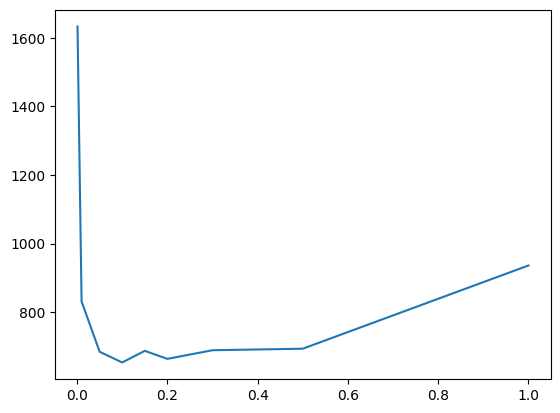

In [8]:
import matplotlib.pyplot as plt

plt.plot(learning_rate_values,errors)
plt.show()

#### Przycinanie drzew

In [9]:
depths = [None, 1, 2, 3, 4]
for depth in depths:
    gbr = GradientBoostingRegressor(max_depth=depth, n_estimators=300, random_state=2)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    rmse = MSE(y_test, y_pred)**0.5
    print('Max Depth:', depth, ', Score:', rmse) 

Max Depth: None , Score: 869.2788645118395
Max Depth: 1 , Score: 707.8261886858736
Max Depth: 2 , Score: 653.7456840231495
Max Depth: 3 , Score: 646.4045923317708
Max Depth: 4 , Score: 663.048387855927


#### subsample - Stochastic Gradient Boosting

In [10]:
samples = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
for sample in samples:
    gbr = GradientBoostingRegressor(max_depth=3, n_estimators=300, subsample=sample, random_state=2)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    rmse = MSE(y_test, y_pred)**0.5
    print('Subsample:', sample, ', Score:', rmse)

Subsample: 1 , Score: 646.4045923317708
Subsample: 0.9 , Score: 620.1819001443569
Subsample: 0.8 , Score: 617.2355650565677
Subsample: 0.7 , Score: 612.9879156983139
Subsample: 0.6 , Score: 622.6385116402317
Subsample: 0.5 , Score: 626.9974073227554


#### RandomizedSearchCV

In [11]:
from sklearn.model_selection import RandomizedSearchCV

params={'subsample':[0.65, 0.7, 0.75],
        'n_estimators':[300, 500, 1000],
         'learning_rate':[0.05, 0.075, 0.1, 0.125]}

gbr = GradientBoostingRegressor(max_depth=3, random_state=2)

rand_reg = RandomizedSearchCV(gbr, params, n_iter=10, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, random_state=2)

rand_reg.fit(X_train, y_train)
best_model = rand_reg.best_estimator_
best_params = rand_reg.best_params_
print("Best params:", best_params)
best_score = np.sqrt(-rand_reg.best_score_)
print("Training score: {:.3f}".format(best_score))
y_pred = best_model.predict(X_test)
rmse_test = MSE(y_test, y_pred)**0.5
print('Test set score: {:.3f}'.format(rmse_test))

Best params: {'subsample': 0.65, 'n_estimators': 300, 'learning_rate': 0.05}
Training score: 636.200
Test set score: 625.985


Po kilku eksperymentach można znaleźć lepsze hiper-parametry.

In [12]:
gbr = GradientBoostingRegressor(max_depth=3, n_estimators=1600, subsample=0.75, learning_rate=0.02, random_state=2)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
MSE(y_test, y_pred)**0.5 

596.9544588974487

In [13]:
from xgboost import XGBRegressor
xg_reg = XGBRegressor(max_depth=3, n_estimators=1600, eta=0.02, subsample=0.75, random_state=2)
xg_reg.fit(X_train, y_train)
y_pred = xg_reg.predict(X_test)
MSE(y_test, y_pred)**0.5

584.3395337495713

# XGBoost - Extreme Gradient Boosting

Funkcja celu w algorytmie XGBoost jest postaci
$$
\operatorname{obj}(\theta)=L(\theta)+\Omega(\theta)
$$
gdzie $L(\theta)$ to funkcja straty, $\Omega(\theta)$ to funkcja kary. Szukamy takiego parametru $\theta$, który minimalizuje funkcję celu.  

Z reguły $L$ to błąd średniokwadratowy (mean squared error)
$$
L(\theta)=\sum_i\left(y_i-\hat{y}_i\right)^2.
$$
Inny przykład to log-loss - funkcja starty używana w regresji logistycznej
$$
L(\theta)=\sum_i\left[y_i \ln \left(1+e^{-\hat{y}_i}\right)+\left(1-y_i\right) \ln \left(1+e^{\hat{y}_i}\right)\right]
$$
Funkcja kary (regularization term) służy do kontrolowania złożoności modelu w celu uniknięcia przetrenowania. 

Składniki modelu należą do rodziny CART (classification and regression trees). Model XGBoost jest postaci:
$$
\hat{y}_i=\sum_{k=1}^K f_k\left(x_i\right), f_k \in \mathcal{F}
$$
gdzie $\mathcal{F}$ to CART. 

Funkcja celu ma wtedy jest postaci
$$
\operatorname{obj}(\theta)=\sum_i^n l\left(y_i, \hat{y}_i\right)+\sum_{k=1}^K \omega\left(f_k\right)
$$
gdzie $\omega\left(f_k\right)$ określa złożoność $f_k$. 

Gdy rozważaną funkcją straty jest błąd średniokwadratowy, to funkcja celu na $t$-tym kroku ma postać
$$
\begin{aligned}
\mathrm{obj}^{(t)} & =\sum_{i=1}^n\left(y_i-\left(\hat{y}_i^{(t-1)}+f_t\left(x_i\right)\right)\right)^2+\sum_{i=1}^t \omega\left(f_i\right) \\
& =\sum_{i=1}^n\left[2\left(\hat{y}_i^{(t-1)}-y_i\right) f_t\left(x_i\right)+f_t\left(x_i\right)^2\right]+\omega\left(f_t\right)+\text { constant }
\end{aligned}
$$

W ogólnym przypadku korzystamy z rozwinięcia Taylora 
$$
\mathrm{obj}^{(t)}=\sum_{i=1}^n\left[l\left(y_i, \hat{y}_i^{(t-1)}\right)+g_i f_t\left(x_i\right)+\frac{1}{2} h_i f_t^2\left(x_i\right)\right]+\omega\left(f_t\right)+\text { constant }
$$
gdzie
$$
\begin{aligned}
g_i & =\partial_{\hat{y}_i^{(t-1)}} l\left(y_i, \hat{y}_i^{(t-1)}\right) \\
h_i & =\partial_{\hat{y}_i^{(t-1)}}^2 l\left(y_i, \hat{y}_i^{(t-1)}\right)
\end{aligned}
$$
Po usunięciu stałych niezależnych of $f_t$ otrzymujemy funkcję celu postaci
$$
\sum_{i=1}^n\left[g_i f_t\left(x_i\right)+\frac{1}{2} h_i f_t^2\left(x_i\right)\right]+\omega\left(f_t\right)
$$

##### Funkcja kary $\omega(f)$

Funkcja kary $\omega(f)$ określa złożoność drzewa. Sformalizujmy definicję drzewa $f(x)$ następująco: 
$$
f_t(x)=w_{q(x)}, w \in R^T, q: R^d \rightarrow\{1,2, \cdots, T\} .
$$
* $T$ jest liczbą wszystkich liści w drzewie $f_t$
* $w=(w_1,w_2,\dots,w_T)$ jest wektorem wyników na liściach, 
* $q$ jest funkcją przypisującą każdy punkt danych do odpowiedniego liścia.

W XGBoost złożoność definiujemy jako
$$
\omega(f)=\gamma T+\frac{1}{2} \lambda \sum_{j=1}^T w_j^2
$$
Funkcja kary jest minimalizowana w trakcie dobierania drzewa. Faworyzowane są drzewa o mniejszej złożoności.  Cześć $\gamma T$ mówi, że lepsze są drzewa o mniejsze liczbie liści. Cześć $\frac{1}{2} \lambda \sum_{j=1}^T w_j^2$ mówi, że jeśli suma kwadratów $\sum w_j^2$ zmniejszy się po dodaniu nowych liści, to będzie to lepsze drzewo. 

Skomplikowane drzewa mają skłonność do przeuczenia. Redukcja złożoności drzew prowadzi do redukcji tego zjawiska. 

##### Ostateczna postać funcji celu

Po przeformułowaniu modelu drzewa możemy zapisać wartość funkcji celu dla $t$-tego drzewa jako:
$$
\begin{aligned}
\mathrm{obj}^{(t)} & \approx \sum_{i=1}^n\left[g_i w_{q\left(x_i\right)}+\frac{1}{2} h_i w_{ q\left(x_i\right)}^2\right]+\gamma T+\frac{1}{2} \lambda \sum_{j=1}^T w_j^2 \\
& =\sum_{j=1}^T\left[\left(\sum_{i \in I_j} g_i\right) w_j+\frac{1}{2}\left(\sum_{i \in I_j} h_i+ \lambda\right) w_j^2\right]+\gamma T
\end{aligned}
$$
gdzie $I_j=\left\{i \mid q\left(x_i\right)=j\right\}$ jest zbiorem indeksów punktów przypisanych do $j$-tego liścia. Zauważmy, że w drugim wierszu zmieniliśmy indeks sumowania, ponieważ wszystkie punkty na tym samym liściu mają ten sam wynik. Możemy dodatkowo uprościć wyrażenie, definiując
$$
\begin{aligned}
& G_j=\sum_{i \in I_j} g_i \text { oraz } H_j=\sum_{i \in I_j} h_i \\
& \text{ i wtedy: }\\
& \mathrm{obj}^{(t)}=\sum_{j=1}^T\left[G_j w_j+\frac{1}{2}\left(H_j+\lambda\right) w_j^2\right] +\gamma T
\end{aligned}
$$

W tym równaniu $w_j$ są niezależne względem siebie, a wyrażenie $G_j w_j+\frac{1}{2}\left(H_j+\lambda\right) w_j^2$ to funkcja kwadratowa zmiennej $w_j$. To wyrażenie minimlizuje się dla 
$$
\begin{aligned}
&w_j^*  =-\frac{G_j}{H_j+\lambda} \\
&\text{W konsekwencji funkcja celu ma postać: }\\
&\mathrm{obj}^*  =-\frac{1}{2} \sum_{j=1}^T \frac{G_j^2}{H_j+\lambda}+\gamma T
\end{aligned}
$$

##### Znajdowanie najlepszego drzewa

Teraz, gdy mamy sposób na zmierzenie, jak dobre jest drzewo, najlepiej byłoby wyliczyć wszystkie możliwe drzewa i wybrać najlepsze. W praktyce jest to trudne, więc będziemy próbować optymalizować jeden poziom drzewa na raz. W szczególności staramy się podzielić liść na dwa liście. Wtedy
$$
\underbrace{\frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{\left(G_L +G_R\right)^2}{H_L+H_R+\lambda}\right]}_{\operatorname{Wzmocnienie}}-\gamma
$$
$G_L+G_R$ oraz $H_L+H_R$ to wartości przed podziałem na lewy (L) i prawy (R) liść. Jeśli wzmocnienie jest mniejsze niż $\gamma$, lepiej nie dodawać tej gałęzi. To technika przycinania (pruning) w modelach opartych na drzewach.

#### Irysy

In [14]:
import pandas as pd
import numpy as np
from sklearn import datasets
iris = datasets.load_iris()

In [15]:
df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],columns= iris['feature_names'] + ['target'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'], random_state=2)

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb = XGBClassifier(booster='gbtree', objective='multi:softprob', max_depth=6, learning_rate=0.1, 
                    n_estimators=100, random_state=2, n_jobs=-1)


booster='gbtree' wartość domyślna

objective='multi:softprob' - funcja celu używana w klasyfikacji w wieloma ($\geq 3$) klasami

In [18]:
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
score = accuracy_score(y_pred, y_test)
print('Score: ' + str(score))

Score: 0.9736842105263158


#### Diabetes dataset

In [19]:
X,y = datasets.load_diabetes(return_X_y=True)
print(datasets.load_diabetes()['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [20]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
xgb = XGBRegressor(booster='gbtree', objective='reg:squarederror', max_depth=6, 
                   learning_rate=0.1, n_estimators=100, random_state=2, n_jobs=-1)

In [21]:
scores = cross_val_score(xgb, X, y, scoring='neg_mean_squared_error', cv=5)

In [22]:
rmse = np.sqrt(-scores)
print('RMSE:', np.round(rmse, 3))
print('RMSE mean: %0.3f' % (rmse.mean()))

RMSE: [63.011 59.705 64.538 63.706 64.588]
RMSE mean: 63.109


Wiecej można przeczytać na stronie https://xgboost.readthedocs.io/en/latest/index.html

#### XGBoost - hiperparametry

In [23]:
import pandas as pd
df = pd.read_csv('heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [26]:
X = df.drop(['target'], axis=1)
y = df['target']

In [27]:
model = XGBClassifier(booster='gbtree', objective='binary:logistic', 
                      random_state=2)

In [28]:
from sklearn.model_selection import cross_val_score
import numpy as np
scores = cross_val_score(model, X, y, cv=5)
print('Accuracy:', np.round(scores, 2))
print('Accuracy mean: %0.2f' % (scores.mean()))

Accuracy: [0.84 0.85 0.82 0.8  0.77]
Accuracy mean: 0.81


In [29]:
from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
scores = cross_val_score(model, X, y, cv=kfold)
print('Accuracy:', np.round(scores, 2))
print('Accuracy mean: %0.2f' % (scores.mean()))

Accuracy: [0.72 0.82 0.75 0.8  0.82]
Accuracy mean: 0.78


In [30]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

def grid_search(params, random=False): 
    xgb = XGBClassifier(booster='gbtree', objective='binary:logistic', random_state=2)
    if random:
        grid = RandomizedSearchCV(xgb, params, cv=kfold, n_iter=20, n_jobs=-1)
    else:
        grid = GridSearchCV(xgb, params, cv=kfold, n_jobs=-1)
    grid.fit(X, y)
    best_params = grid.best_params_
    print("Best params:", best_params)
    best_score = grid.best_score_
    print("Training score: {:.3f}".format(best_score))
    

##### n_estimators

In [31]:
grid_search(params={'n_estimators':[100, 200, 400, 800]})

Best params: {'n_estimators': 100}
Training score: 0.782


##### learning_rate

In [32]:
grid_search(params={'learning_rate':[0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]})

Best params: {'learning_rate': 0.05}
Training score: 0.796


##### max_depth

In [33]:
grid_search(params={'max_depth':[2, 3, 5, 6, 8]})

Best params: {'max_depth': 2}
Training score: 0.799


##### gamma

In [34]:
grid_search(params={'gamma':[0, 0.1, 0.5, 1, 2, 5]})

Best params: {'gamma': 0.5}
Training score: 0.796


##### min_child_weight
**min_child_weight** to minimalna sumy wag, aby podzielić liść na dwa. Jeśli suma wag jest mniejsza niż wartość **min_child_weight**, dalsze podziały nie są wykonywane. **min_child_weight** zmniejsza przeuczenie, gdy zwiększa się jego wartość. 

In [35]:
grid_search(params={'min_child_weight':[1, 2, 3, 4, 5]})

Best params: {'min_child_weight': 5}
Training score: 0.812


##### subsample
**subsample** określa procent wierszy branych w każdym kroku boostingu. Zmienjszając **subsample** poniżej 100% zmniejszamy przeuczenie.

In [36]:
grid_search(params={'subsample':[0.5, 0.7, 0.8, 0.9, 1]})

Best params: {'subsample': 0.8}
Training score: 0.796


##### colsample_bytree
Procent kolumn danych brany do trenowania drzew

In [37]:
grid_search(params={'colsample_bytree':[0.5, 0.7, 0.8, 0.9, 1]})

Best params: {'colsample_bytree': 0.9}
Training score: 0.799


#### Wczesne zatrzymanie - early stopping

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2)
model = XGBClassifier(booster='gbtree', objective='binary:logistic', random_state=2)
eval_set = [(X_test, y_test)]
eval_metric = 'error' # 'rmse' dla regresji
model.fit(X_train, y_train, eval_metric=eval_metric, eval_set=eval_set)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

[0]	validation_0-error:0.15789
[1]	validation_0-error:0.10526
[2]	validation_0-error:0.11842
[3]	validation_0-error:0.13158
[4]	validation_0-error:0.11842
[5]	validation_0-error:0.14474
[6]	validation_0-error:0.14474
[7]	validation_0-error:0.14474
[8]	validation_0-error:0.14474
[9]	validation_0-error:0.14474
[10]	validation_0-error:0.14474
[11]	validation_0-error:0.15789
[12]	validation_0-error:0.15789
[13]	validation_0-error:0.17105
[14]	validation_0-error:0.17105
[15]	validation_0-error:0.17105
[16]	validation_0-error:0.15789
[17]	validation_0-error:0.17105
[18]	validation_0-error:0.15789
[19]	validation_0-error:0.17105
[20]	validation_0-error:0.17105
[21]	validation_0-error:0.17105
[22]	validation_0-error:0.18421
[23]	validation_0-error:0.18421
[24]	validation_0-error:0.17105
[25]	validation_0-error:0.18421
[26]	validation_0-error:0.18421
[27]	validation_0-error:0.18421
[28]	validation_0-error:0.18421
[29]	validation_0-error:0.18421
[30]	validation_0-error:0.18421
[31]	validation_0-

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[37]	validation_0-error:0.18421
[38]	validation_0-error:0.18421
[39]	validation_0-error:0.18421
[40]	validation_0-error:0.18421
[41]	validation_0-error:0.18421
[42]	validation_0-error:0.18421
[43]	validation_0-error:0.17105
[44]	validation_0-error:0.18421
[45]	validation_0-error:0.17105
[46]	validation_0-error:0.18421
[47]	validation_0-error:0.18421
[48]	validation_0-error:0.17105
[49]	validation_0-error:0.15789
[50]	validation_0-error:0.17105
[51]	validation_0-error:0.17105
[52]	validation_0-error:0.15789
[53]	validation_0-error:0.17105
[54]	validation_0-error:0.17105
[55]	validation_0-error:0.17105
[56]	validation_0-error:0.17105
[57]	validation_0-error:0.17105
[58]	validation_0-error:0.17105
[59]	validation_0-error:0.17105
[60]	validation_0-error:0.17105
[61]	validation_0-error:0.17105
[62]	validation_0-error:0.17105
[63]	validation_0-error:0.17105
[64]	validation_0-error:0.17105
[65]	validation_0-error:0.17105
[66]	validation_0-error:0.18421
[67]	validation_0-error:0.18421
[68]	val

##### early_stopping_rounds

In [39]:
model = XGBClassifier(booster='gbtree', objective='binary:logistic', random_state=2)
eval_set = [(X_test, y_test)]
eval_metric='error'
model.fit(X_train, y_train, eval_metric="error", eval_set=eval_set, 
          early_stopping_rounds=10, verbose=True)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

[0]	validation_0-error:0.15789
[1]	validation_0-error:0.10526
[2]	validation_0-error:0.11842
[3]	validation_0-error:0.13158
[4]	validation_0-error:0.11842
[5]	validation_0-error:0.14474
[6]	validation_0-error:0.14474
[7]	validation_0-error:0.14474
[8]	validation_0-error:0.14474
[9]	validation_0-error:0.14474
[10]	validation_0-error:0.14474
[11]	validation_0-error:0.15789
Accuracy: 89.47%


C:\Users\HP\anaconda3\envs\wad\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
C:\Users\HP\anaconda3\envs\wad\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


In [40]:
model = XGBClassifier(random_state=2, n_estimators=5000)
eval_set = [(X_test, y_test)]
eval_metric="error"
model.fit(X_train, y_train, eval_metric=eval_metric, eval_set=eval_set, early_stopping_rounds=100)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

[0]	validation_0-error:0.15789
[1]	validation_0-error:0.10526
[2]	validation_0-error:0.11842
[3]	validation_0-error:0.13158
[4]	validation_0-error:0.11842
[5]	validation_0-error:0.14474
[6]	validation_0-error:0.14474
[7]	validation_0-error:0.14474
[8]	validation_0-error:0.14474
[9]	validation_0-error:0.14474
[10]	validation_0-error:0.14474


C:\Users\HP\anaconda3\envs\wad\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
C:\Users\HP\anaconda3\envs\wad\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[11]	validation_0-error:0.15789
[12]	validation_0-error:0.15789
[13]	validation_0-error:0.17105
[14]	validation_0-error:0.17105
[15]	validation_0-error:0.17105
[16]	validation_0-error:0.15789
[17]	validation_0-error:0.17105
[18]	validation_0-error:0.15789
[19]	validation_0-error:0.17105
[20]	validation_0-error:0.17105
[21]	validation_0-error:0.17105
[22]	validation_0-error:0.18421
[23]	validation_0-error:0.18421
[24]	validation_0-error:0.17105
[25]	validation_0-error:0.18421
[26]	validation_0-error:0.18421
[27]	validation_0-error:0.18421
[28]	validation_0-error:0.18421
[29]	validation_0-error:0.18421
[30]	validation_0-error:0.18421
[31]	validation_0-error:0.18421
[32]	validation_0-error:0.18421
[33]	validation_0-error:0.18421
[34]	validation_0-error:0.18421
[35]	validation_0-error:0.18421
[36]	validation_0-error:0.18421
[37]	validation_0-error:0.18421
[38]	validation_0-error:0.18421
[39]	validation_0-error:0.18421
[40]	validation_0-error:0.18421
[41]	validation_0-error:0.18421
[42]	val

#### Dobieranie hiperparametrów krok po kroku

In [41]:
grid_search(params={'n_estimators':[2, 25, 50, 75, 100]})

Best params: {'n_estimators': 50}
Training score: 0.789


In [42]:
grid_search(params={'max_depth':[1, 2, 3, 4, 5, 6, 7, 8], 
                    'n_estimators':[50]})

Best params: {'max_depth': 1, 'n_estimators': 50}
Training score: 0.839


In [43]:
grid_search(params={'max_depth':[1, 2, 3, 4, 6, 7, 8], 
                    'n_estimators':[2, 50, 100]})

Best params: {'max_depth': 1, 'n_estimators': 50}
Training score: 0.839


In [44]:
grid_search(params={'learning_rate':[0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5], 'max_depth':[1], 'n_estimators':[50]})

Best params: {'learning_rate': 0.3, 'max_depth': 1, 'n_estimators': 50}
Training score: 0.839


Zauważmy, że **learning_rate = 0.3** to domyślna wartość dla XGBoost

In [45]:
grid_search(params={'min_child_weight':[1, 2, 3, 4, 5], 'max_depth':[1], 'n_estimators':[50]})

Best params: {'max_depth': 1, 'min_child_weight': 1, 'n_estimators': 50}
Training score: 0.839


 Zauważmy, że 1 to wartość domyślna **min_child_weight**.

Zróbmy to samo używając RandomGridSearch

In [46]:
grid_search(params={'subsample':[0.5, 0.6, 0.7, 0.8, 0.9, 1], 
                    'min_child_weight':[1, 2, 3, 4, 5], 
                    'learning_rate':[0.1, 0.2, 0.3, 0.4, 0.5], 
                    'max_depth':[1, 2, 3, 4, 5, None], 
                    'n_estimators':[2, 25, 50, 75, 100]},
                    random=True)

Best params: {'subsample': 1, 'n_estimators': 75, 'min_child_weight': 1, 'max_depth': 1, 'learning_rate': 0.4}
Training score: 0.822


Wypróbujmy teraz **colsample_bytree**, **colsample_bylevel** i **colsample_bynode**.

In [47]:
grid_search(params={'colsample_bytree':[0.5, 0.6, 0.7, 0.8, 0.9, 1], 'max_depth':[1], 'n_estimators':[50]})

Best params: {'colsample_bytree': 0.8, 'max_depth': 1, 'n_estimators': 50}
Training score: 0.842


In [48]:
grid_search(params={'colsample_bylevel':[0.5, 0.6, 0.7, 0.8, 0.9, 1],'max_depth':[1], 'n_estimators':[50], 
                    'colsample_bytree':[0.8]})

Best params: {'colsample_bylevel': 1, 'colsample_bytree': 0.8, 'max_depth': 1, 'n_estimators': 50}
Training score: 0.842


In [49]:
grid_search(params={'colsample_bynode':[0.5, 0.6, 0.7, 0.8, 0.9, 1], 'colsample_bylevel':[0.5, 0.6, 0.7, 0.8, 0.9, 1], 
                    'colsample_bytree':[0.5, 0.6, 0.7, 0.8, 0.9, 1], 'max_depth':[1], 'n_estimators':[50]})

Best params: {'colsample_bylevel': 0.6, 'colsample_bynode': 0.8, 'colsample_bytree': 0.7, 'max_depth': 1, 'n_estimators': 50}
Training score: 0.852


In [50]:
grid_search(params={'gamma':[0, 0.01, 0.05, 0.1, 0.5, 1, 2, 3], 'colsample_bylevel': [0.6], 'colsample_bynode': [0.8], 
                    'colsample_bytree': [0.7], 'max_depth': [1], 'n_estimators': [50]})

Best params: {'colsample_bylevel': 0.6, 'colsample_bynode': 0.8, 'colsample_bytree': 0.7, 'gamma': 0, 'max_depth': 1, 'n_estimators': 50}
Training score: 0.852


**gamma = 0** to wartość domyślna